# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


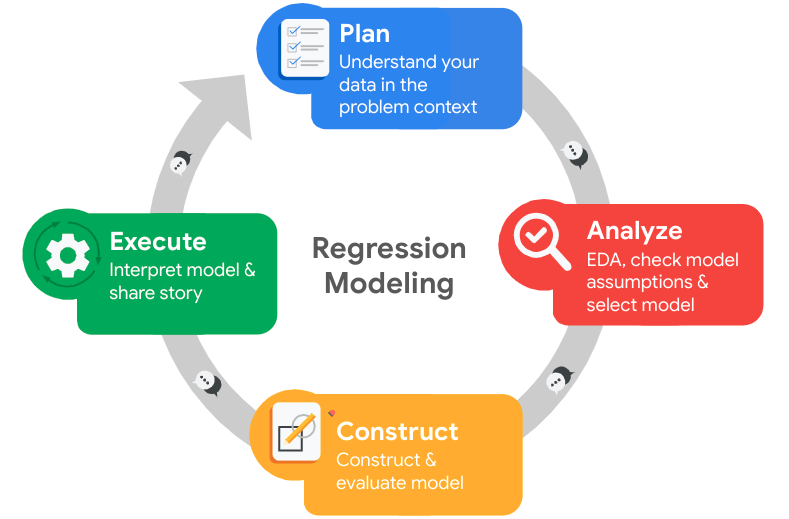

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,ConfusionMatrixDisplay,confusion_matrix,roc_auc_score
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [4]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [5]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [6]:
# Display all column names
print(df0.columns)

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')


In [3]:
# Rename columns as needed
df0=df0.rename(columns={'average_montly_hours':'avg_monthly_hours','Work_accident':'work_accident'})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'avg_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [4]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
avg_monthly_hours        0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [4]:
# Check for duplicates
dup=df0.duplicated()
df0.duplicated().sum()

3008

In [21]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,no_of_years,work_accident,left,promotion_last_5years,Department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [5]:
# Drop duplicates and save resulting dataframe in a new variable as needed

df0=df0.drop_duplicates().reset_index(drop=True)
# Display first few rows of new dataframe as needed
df0.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

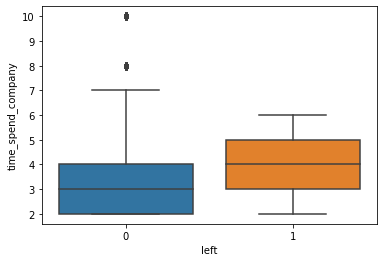

In [6]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers

sns.boxplot(data=df0,x='left',y='time_spend_company',showfliers=True)

In [6]:
# Determine the number of rows containing outliers
q1=df0['time_spend_company'].quantile(0.25)
q2=df0['time_spend_company'].quantile(0.50)
q3=df0['time_spend_company'].quantile(0.75)
median=df0['time_spend_company'].median()
iqr=q3-q1
max_outlier=q3+1.5*iqr
min_outlier=q1-1.5*iqr
outliers=(df0['time_spend_company']>max_outlier) |(df0['time_spend_company']<min_outlier)
num_outliers=outliers.sum()
num_outliers

824

Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [7]:
# Get numbers of people who left vs. stayed
num_stayed=(df0['left']==0).sum()
num_left=(df0['left']==1).sum()
print("number of people stayed",num_stayed)
print("number of people left",num_left)
# Get percentages of people who left vs. stayed
total_emps=len(df0)
percentage_stayed=(num_stayed/total_emps)*100
percentage_left=(num_left/total_emps)*100
print('percentage stayed',percentage_stayed)
print('percentage left',percentage_left)

number of people stayed 10000
number of people left 1991
percentage stayed 83.39588024351598
percentage left 16.604119756484028


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

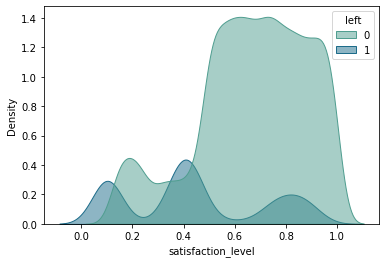

In [9]:
# Create a plot as needed
sns.kdeplot(data=df0,x='satisfaction_level',hue='left',fill=True,alpha=0.5,palette='crest')

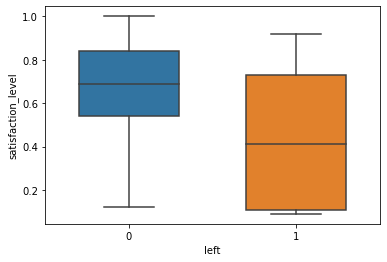

In [10]:
# Create a plot as needed
sns.boxplot(data=df0,x='left',y='satisfaction_level',showfliers=True,width=0.6)

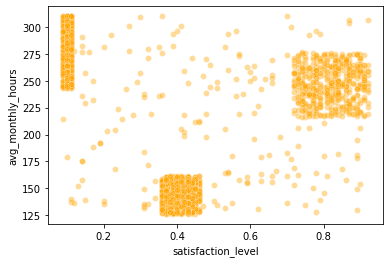

In [11]:
# Create a plot as needed
sns.scatterplot(data=df0[df0['left']==1],x='satisfaction_level',y='avg_monthly_hours',alpha=0.4,color='orange')

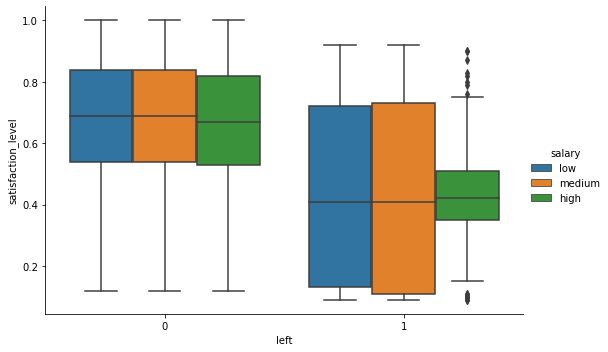

In [12]:
# Create a plot as needed
sns.catplot(data=df0,x='left',y='satisfaction_level',hue='salary',kind='box',aspect=1.5)

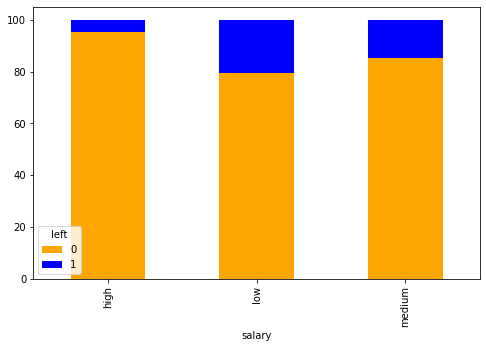

In [13]:
# Create a plot as needed
pivot_df=pd.crosstab(df0['salary'],df0['left'],normalize='index')*100
pivot_df.plot(kind='bar',stacked=True,color=['orange','blue'],figsize=(8,5))

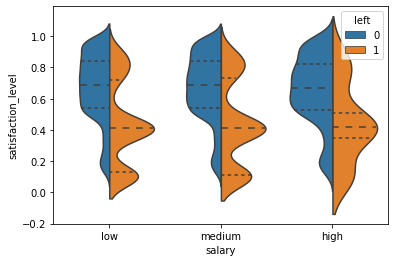

In [27]:
# Create a plot as needed
sns.violinplot(data=df0,x='salary',y='satisfaction_level',hue='left',split=True,inner='quart')

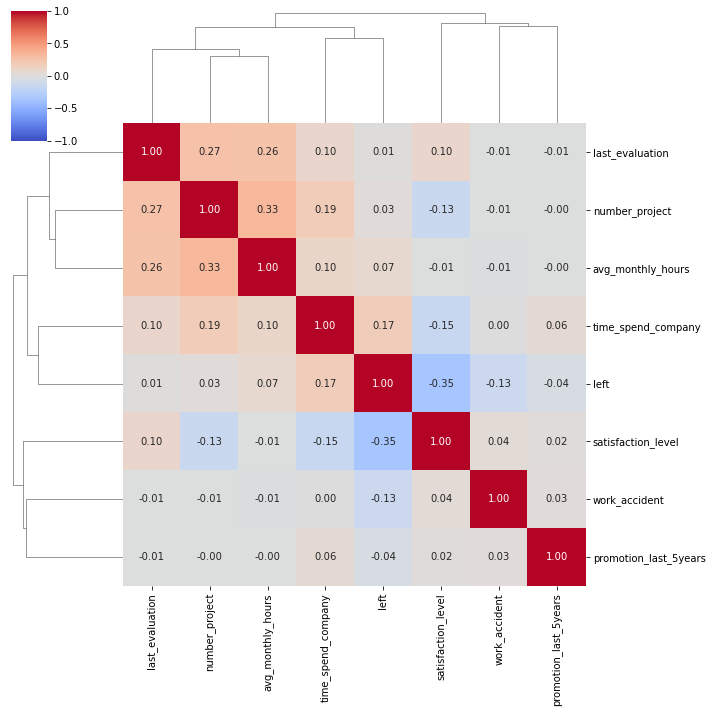

In [31]:
# Create a plot as needed
corr_matrix = df0.select_dtypes(include='number').corr()
sns.clustermap(data=corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmax=1, vmin=-1)

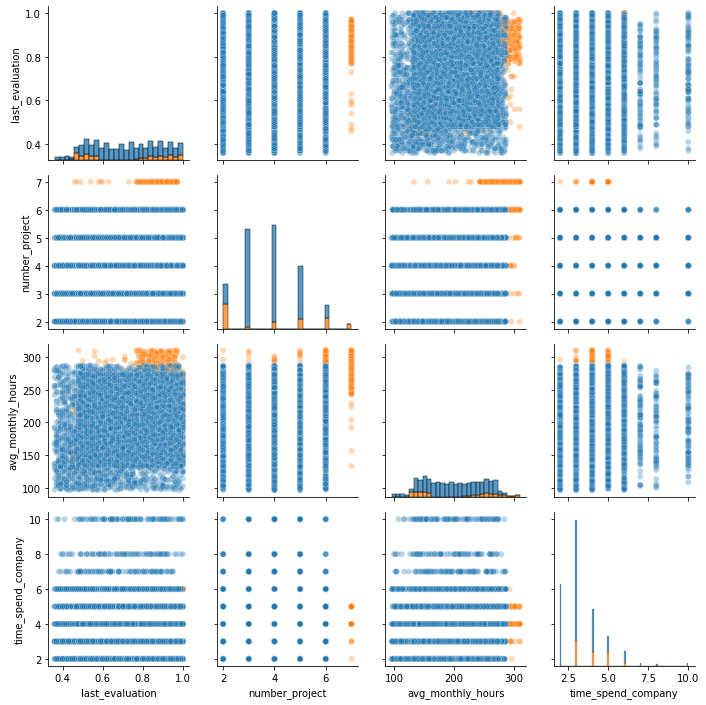

In [11]:
# Create a plot as needed
g=sns.PairGrid(data=df0[['last_evaluation','number_project','avg_monthly_hours','time_spend_company','left']],hue='left')
g.map_diag(sns.histplot,multiple='stack')
g.map_offdiag(sns.scatterplot,alpha=0.3)

### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



[Double-click to enter your responses here.]

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

[Double-click to enter your responses here.]

### Identify the types of models most appropriate for this task.

[Double-click to enter your responses here.]

### Modeling

Add as many cells as you need to conduct the modeling process.

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



In [9]:
y=df0['left']
X=df0.copy()
X=X.drop(['left','Department','salary'],axis=1)
X.head()

,satisfaction_level,last_evaluation,number_project,avg_monthly_hours,time_spend_company,work_accident,promotion_last_5years
0,0.38,0.53,2,157,3,0,0
1,0.80,0.86,5,262,6,0,0
2,0.11,0.88,7,272,4,0,0
3,0.72,0.87,5,223,5,0,0
4,0.37,0.52,2,159,3,0,0


In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
lgr=LogisticRegression(class_weight='balanced',solver='liblinear').fit(X_train,y_train)
lgr.intercept_
lgr.coef_

array([[-4.41783256,  1.1436743 , -0.39290626,  0.00502669,  0.43467067,
        -1.46470852, -1.7036045 ]])

In [11]:
y_pred=lgr.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [12]:
print('recall score: ',recall_score(y_test,y_pred))
print('accuracy score: ',accuracy_score(y_test,y_pred))
print('precision score: ',precision_score(y_test,y_pred))
print('f1 score',f1_score(y_test,y_pred))
print('AUC score',roc_auc_score(y_test,y_pred))

recall score:  0.7901119402985075
accuracy score:  0.7528888888888889
precision score:  0.4884659746251442
f1 score 0.6037063435495367
AUC score 0.765680240861039


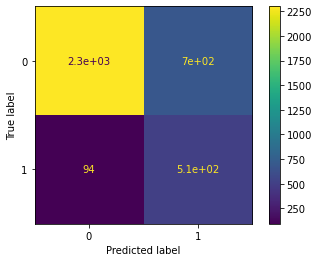

In [12]:
cm=confusion_matrix(y_test,y_pred,labels=lgr.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=lgr.classes_)
disp.plot()
plt.show()

In [14]:
rf=RandomForestClassifier(random_state=42)
cv_params={'max_depth':[2,3,4,5,None],
          'min_samples_leaf':[1,2,3],
          'min_samples_split':[2,3,4],
          'max_features':[2,3,4],
          'n_estimators':[75,100,125,150]}
scoring=['accuracy','recall','precision','f1']
rf_cv=GridSearchCV(rf,cv_params,scoring=scoring,cv=5,refit='f1')
rf_cv.fit(X_train,y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False, random_state=42,
                                  

In [17]:
with open('rf_cv_model.pickle','wb') as to_write:
    pickle.dump(rf_cv,to_write)

In [6]:
with open('rf_cv_model.pickle','rb') as to_read:
    rf_cv=pickle.load(to_read)

In [7]:
rf_best_model=rf_cv.best_estimator_
print('best avg score',rf_cv.best_score_)

best avg score 0.955528051095613


In [13]:
def make_result(model_name,model_object):
    cv_results=pd.DataFrame(model_object.cv_results_)
    best_estimator_results=cv_results.iloc[cv_results['mean_test_f1'].idxmax(),:]
    f1=best_estimator_results.mean_test_f1
    recall=best_estimator_results.mean_test_recall
    accuracy=best_estimator_results.mean_test_accuracy
    precision=best_estimator_results.mean_test_precision
    table=pd.DataFrame({'model':[model_name],
                       'F1':[f1],
                       'recall':[recall],
                       'accuracy':[accuracy],
                       'precision':[precision]})
    return table
rf_cv_results=make_result('random forest cv',rf_cv)
rf_cv_results
lgr_df=pd.DataFrame({'model':['Logistic Regression'],
                    'F1':[f1_score(y_test,y_pred)],
                    'recall':[recall_score(y_test,y_pred)],
                    'accuracy':[accuracy_score(y_test,y_pred)],
                    'precision':[precision_score(y_test,y_pred)] 
                    })
comp_table=pd.concat([lgr_df,rf_cv_results],ignore_index=True).sort_values(by='F1',ascending=False)
comp_table

,model,F1,recall,accuracy,precision
1,random forest cv,0.955528,0.921476,0.985822,0.992271
0,Logistic Regression,0.603706,0.790112,0.752889,0.488466


In [14]:
rf_pred=rf_cv.best_estimator_.predict(X_test)
print("Best Model Scores")
print("accuracy score: ",accuracy_score(y_test,rf_pred))
print("recall score: ",recall_score(y_test,rf_pred))
print("f1 score: ",f1_score(y_test,rf_pred))
print("precision score: ",precision_score(y_test,rf_pred))
print('AUC score',roc_auc_score(y_test,rf_pred))

Best Model Scores
accuracy score:  0.9833333333333333
recall score:  0.9365671641791045
f1 score:  0.9639942390782524
precision score:  0.9930761622156281
AUC score 0.9672625785889688


In [15]:
rf_cv.best_estimator_.feature_importances_

array([4.22495266e-01, 1.07908652e-01, 1.84495089e-01, 1.45585050e-01,
       1.38111372e-01, 1.08545572e-03, 3.19115296e-04])

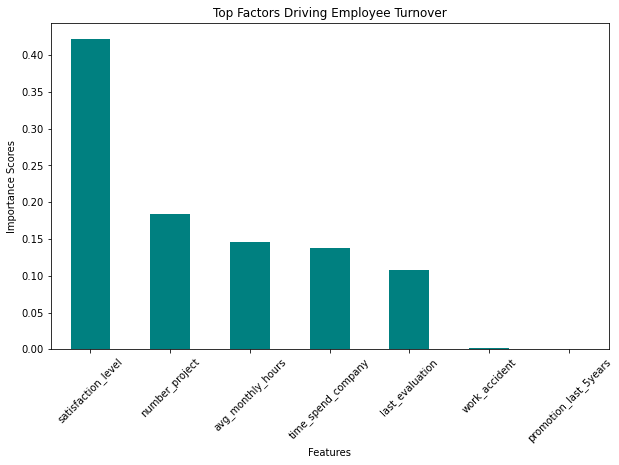

In [19]:
feat_imp=pd.Series(rf_cv.best_estimator_.feature_importances_,index=X.columns)
plt.figure(figsize=(10,6))
feat_imp.nlargest(10).plot(kind='bar',color='teal')
plt.title('Top Factors Driving Employee Turnover')
plt.xlabel('Features')
plt.ylabel('Importance Scores')
plt.xticks(rotation=45)
plt.show()

In [37]:
Left_features=df0.groupby('left')[['satisfaction_level','number_project','avg_monthly_hours','time_spend_company','last_evaluation','work_accident','promotion_last_5years']].mean()
Left_features

,satisfaction_level,number_project,avg_monthly_hours,time_spend_company,last_evaluation,work_accident,promotion_last_5years
left,,,,,,,
0,0.667365,3.786800,198.94270,3.262000,0.715667,0.174500,0.019500
1,0.440271,3.883476,208.16223,3.881467,0.721783,0.052737,0.004018


In [41]:
df0[df0['left']==1]['number_project'].value_counts().sort_index()

2    857
3     38
4    237
5    343
6    371
7    145
Name: number_project, dtype: int64

✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The Random Forest Model concluded that the satisfaction level of the employees is the main driving factor behind employee turnover, showing a clear negative correlation (lower satisfaction levels equals higher turnover), along with increased workloads (number of projects and the average monthly hours working).

### Conclusion, Recommendations, Next Steps
In order to improve overall employee retention, Salifort Motors must work on reducing employee workloads in order to reduce employee stress and burnout. Some key recommendations that could be offered here are:

Cap the monthly hours: Since the satisfaction level is the key driver of the turnover, Salifort Motors must work towards increasing employee satisfaction levels by reducing the average monthly hours that they have to work.

Project distribution: It has come to notice that the employees offered 2 or less projects and those that get assigned 6 or more projects also tend to leave more often.

Project safe-zone: Therefore, it would be better to assign employees with about 3-5 projects as their skills and efforts wouldn't be underutilized nor cause them extreme burnout.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.